# House Prices Prediction (Kaggle)

## Project Overview
This project aims to predict house prices using advanced regression techniques on the Kaggle House Prices dataset.

The workflow includes:
- Data preprocessing
- Feature selection
- Exploratory Data Analysis (EDA)
- Feature engineering
- Ensemble learning (stacking)

---

##   Results
- Kaggle Ranking: **Top 0.12%**
- Model: **Stacking Ensemble (Ridge + RF + GBR + LightGBM)**
- Metric: **RMSE (log scale)**

---

## Table of Contents
- [1. Data Loading](#1-data-loading)
- [2. Data Preprocessing](#2-data-preprocessing)
- [3. Feature Selection](#3-feature-selection)
- [4. Exploratory Data Analysis](#4-exploratory-data-analysis)
- [5. Target Transformation](#5-target-transformation)
- [6. Outlier Removal](#6-outlier-removal)
- [7. Missing Value Handling](#7-missing-value-handling)
- [8. Feature Engineering](#8-feature-engineering)
- [9. Encoding](#9-encoding)
- [10. Model Building](#10-model-building)
- [11. Stacking Ensemble](#11-stacking-ensemble)
- [12. Prediction & Submission](#12-prediction--submission)

In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## 1. Data Loading
Load training and test datasets from Kaggle input directory.

In [79]:
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')


In [80]:
X = train_df.copy()
y = X.pop("SalePrice")
X = X.drop("Id", axis=1)


## 2. Data Preprocessing

- Separate target variable (`SalePrice`)
- Remove ID column
- Encode categorical variables using factorization
- Fill missing values

In [81]:
for colname in X.select_dtypes(["object", "category"]):
    X[colname], _ = X[colname].factorize()
X = X.fillna(X.median())
discrete_features = X.dtypes == int
discrete_features

MSSubClass        True
MSZoning          True
LotFrontage      False
LotArea           True
Street            True
                 ...  
MiscVal           True
MoSold            True
YrSold            True
SaleType          True
SaleCondition     True
Length: 79, dtype: bool

## 3. Feature Selection

We use **Mutual Information (MI)** to evaluate feature importance.

- Captures nonlinear relationships
- Helps identify key predictors

In [82]:
mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores.sort_values(ascending = False).head(20)

OverallQual     0.578650
Neighborhood    0.525390
GarageArea      0.492795
GrLivArea       0.432808
YearBuilt       0.408715
TotalBsmtSF     0.399518
LotArea         0.392427
GarageCars      0.360102
BsmtQual        0.331398
ExterQual       0.325150
KitchenQual     0.322472
GarageYrBlt     0.298833
1stFlrSF        0.283265
MSSubClass      0.278183
YearRemodAdd    0.275659
FullBath        0.273156
GarageFinish    0.262945
LotFrontage     0.217830
FireplaceQu     0.209348
TotRmsAbvGrd    0.207962
Name: MI Scores, dtype: float64

## 4. Exploratory Data Analysis

We explore feature-target relationships using:

- Scatter plots
- Regression plots
- Distribution visualization
- Correlation heatmap

In [83]:
scores = mi_scores.sort_values().tail(30)
width = np.arange(len(scores))
scores

BsmtUnfSF       0.127348
Exterior2nd     0.155076
BsmtFinType1    0.156648
BsmtFinSF1      0.156693
2ndFlrSF        0.167814
Fireplaces      0.170253
HeatingQC       0.173586
OpenPorchSF     0.189047
Foundation      0.192939
GarageType      0.201902
TotRmsAbvGrd    0.207962
FireplaceQu     0.209348
LotFrontage     0.217830
GarageFinish    0.262945
FullBath        0.273156
YearRemodAdd    0.275659
MSSubClass      0.278183
1stFlrSF        0.283265
GarageYrBlt     0.298833
KitchenQual     0.322472
ExterQual       0.325150
BsmtQual        0.331398
GarageCars      0.360102
LotArea         0.392427
TotalBsmtSF     0.399518
YearBuilt       0.408715
GrLivArea       0.432808
GarageArea      0.492795
Neighborhood    0.525390
OverallQual     0.578650
Name: MI Scores, dtype: float64

In [84]:
ticks = list(scores.index)
features_to_plot = ticks[::-1]

Text(0.5, 1.0, 'Mutual Information Scores')

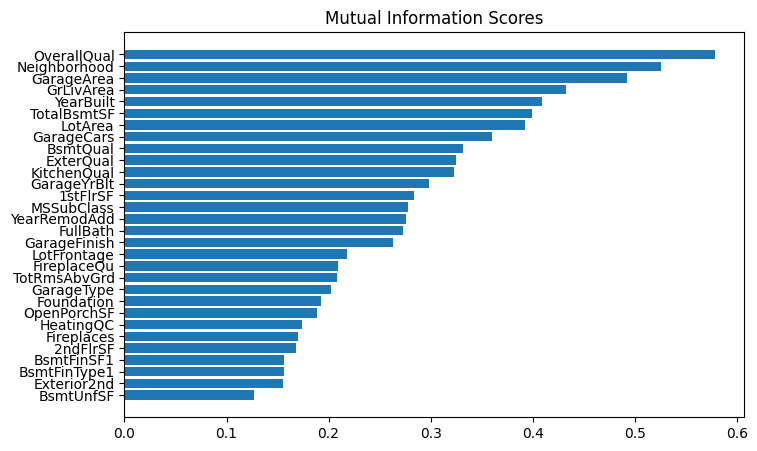

In [85]:
plt.figure(dpi=100, figsize=(8, 5))
plt.barh(width, scores)
plt.yticks(width, ticks)
plt.title("Mutual Information Scores")

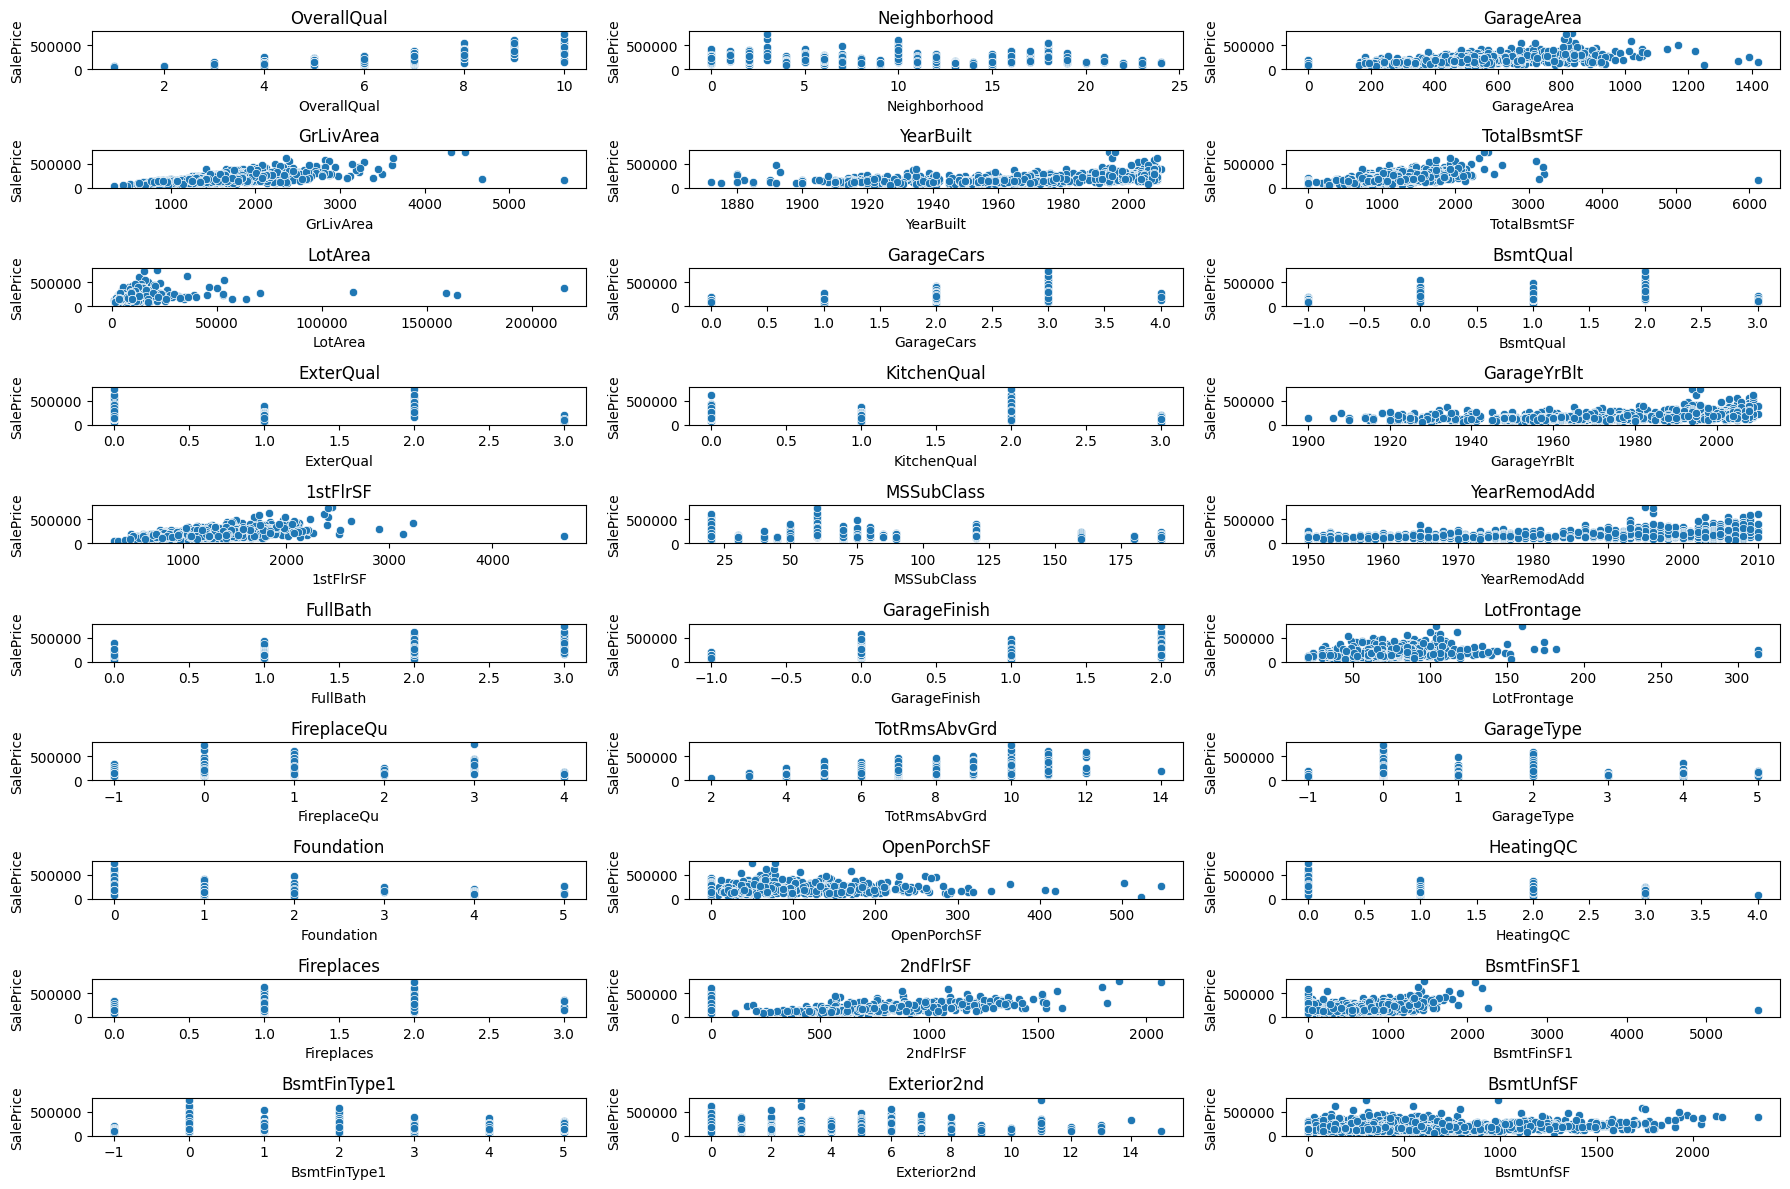

In [86]:
plot_df = X.copy()
plot_df["SalePrice"] = y
plt.figure(figsize=(18,12))
for i, feature in enumerate(features_to_plot,1):
    plt.subplot(10,3,i)
    sns.scatterplot(x=feature,y='SalePrice',data=plot_df)
    plt.title(feature)
plt.tight_layout()
plt.show()


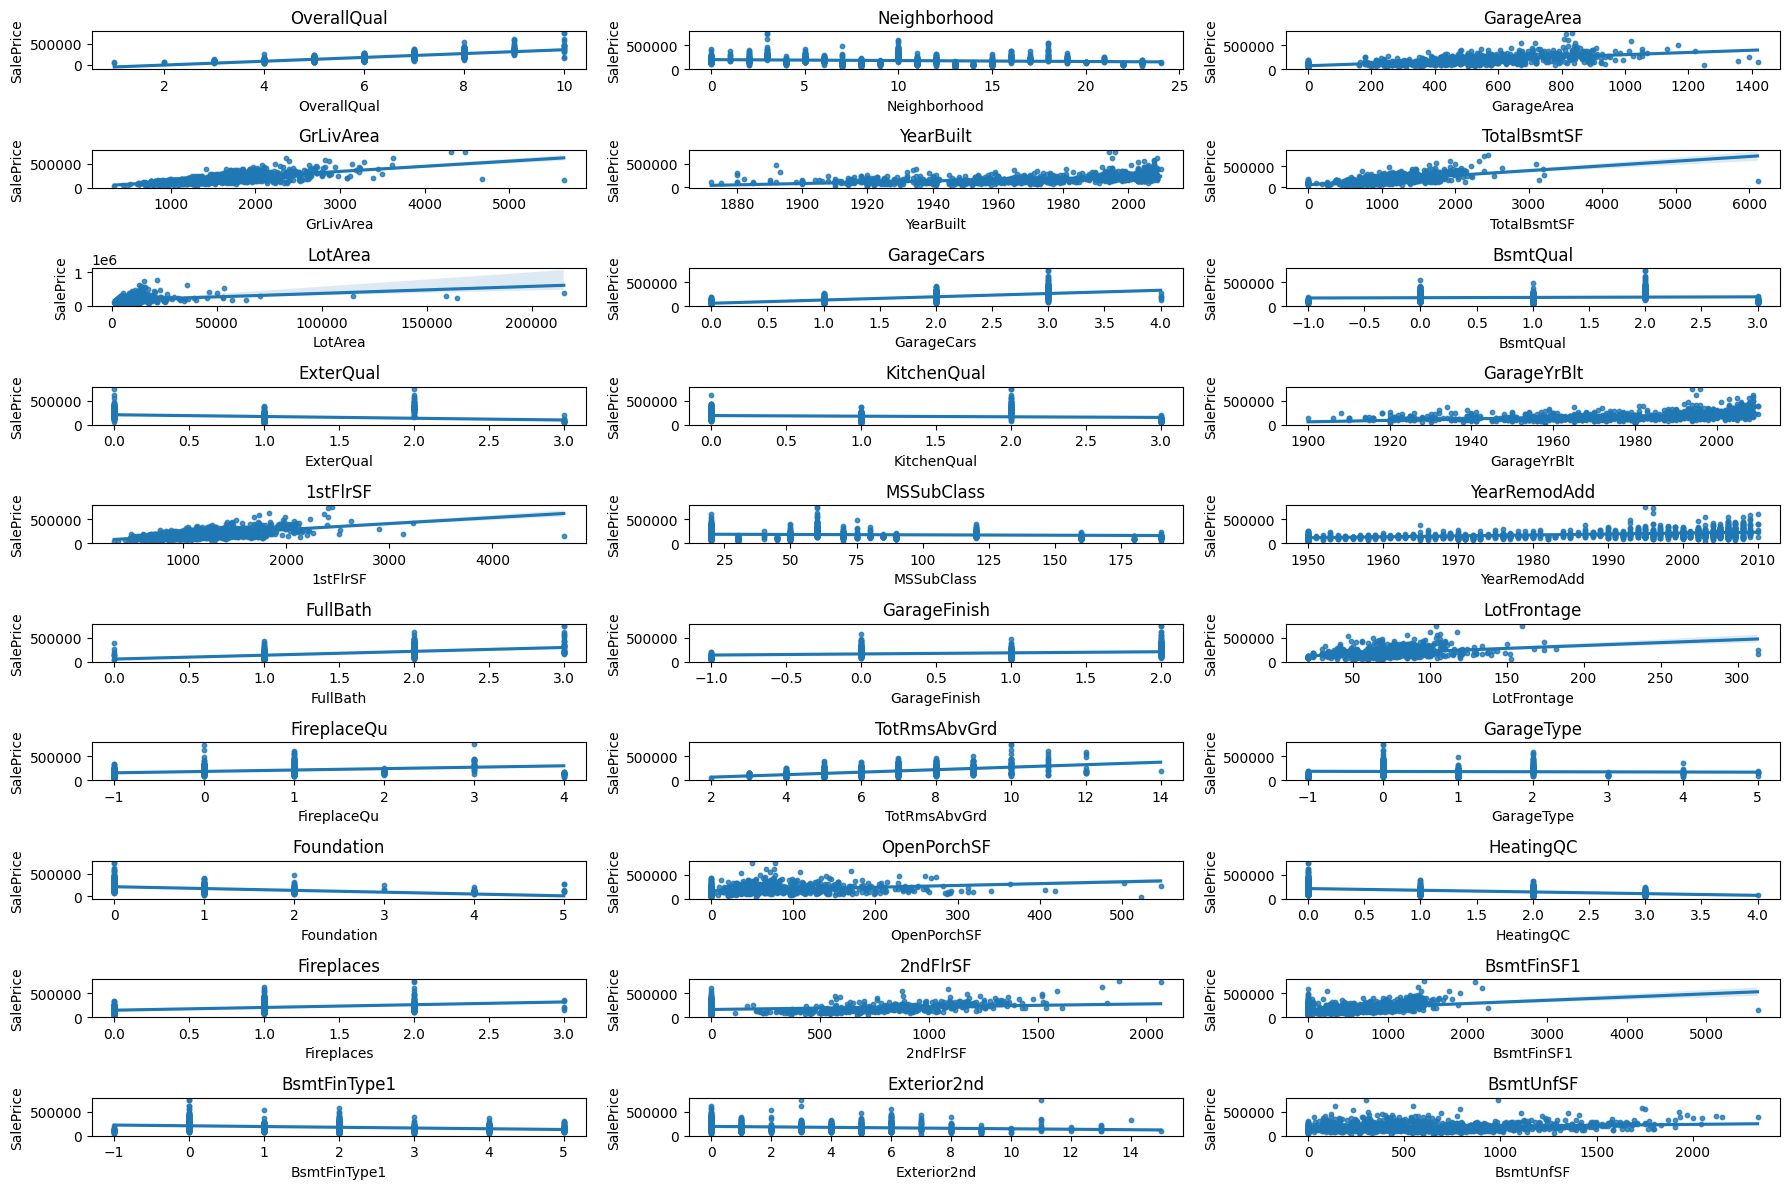

In [87]:
plt.figure(figsize=(18,12))
for i, feature in enumerate(features_to_plot,1):
    plt.subplot(10,3,i)
    sns.regplot(x=feature, y="SalePrice", data=plot_df, scatter_kws={"s":10})
    plt.title(feature)
plt.tight_layout()    
plt.show()

## 5. Target Transformation

The target variable is right-skewed.

- Apply `log1p` transformation
- Improves normality and model performance

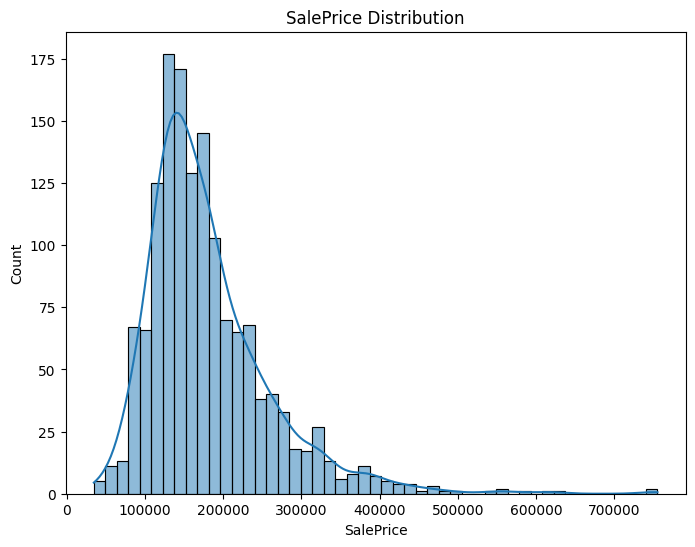

Skew: 1.8828757597682129
Kurtosis: 6.536281860064529


In [88]:
plt.figure(figsize=(8,6))
sns.histplot(y,kde=True)
plt.title("SalePrice Distribution")
plt.show()

print("Skew:", train_df["SalePrice"].skew())
print("Kurtosis:", train_df["SalePrice"].kurt())

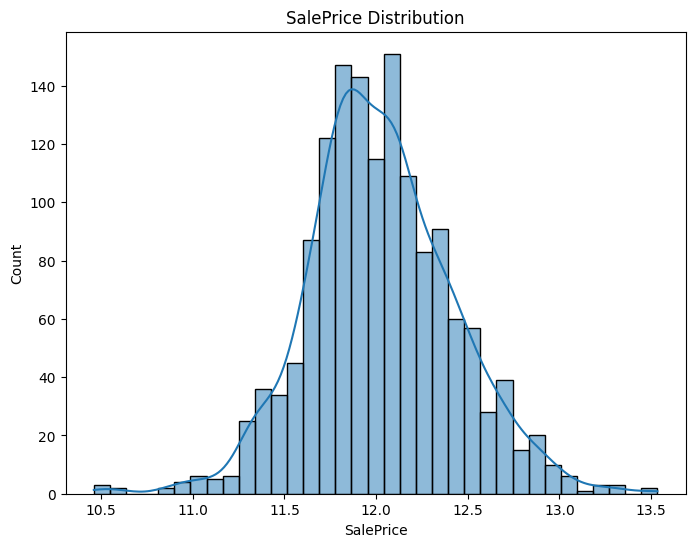

In [89]:
y = np.log1p(y)
plt.figure(figsize=(8,6))
sns.histplot(y,kde=True)
plt.title("SalePrice Distribution")
plt.show()


<Axes: >

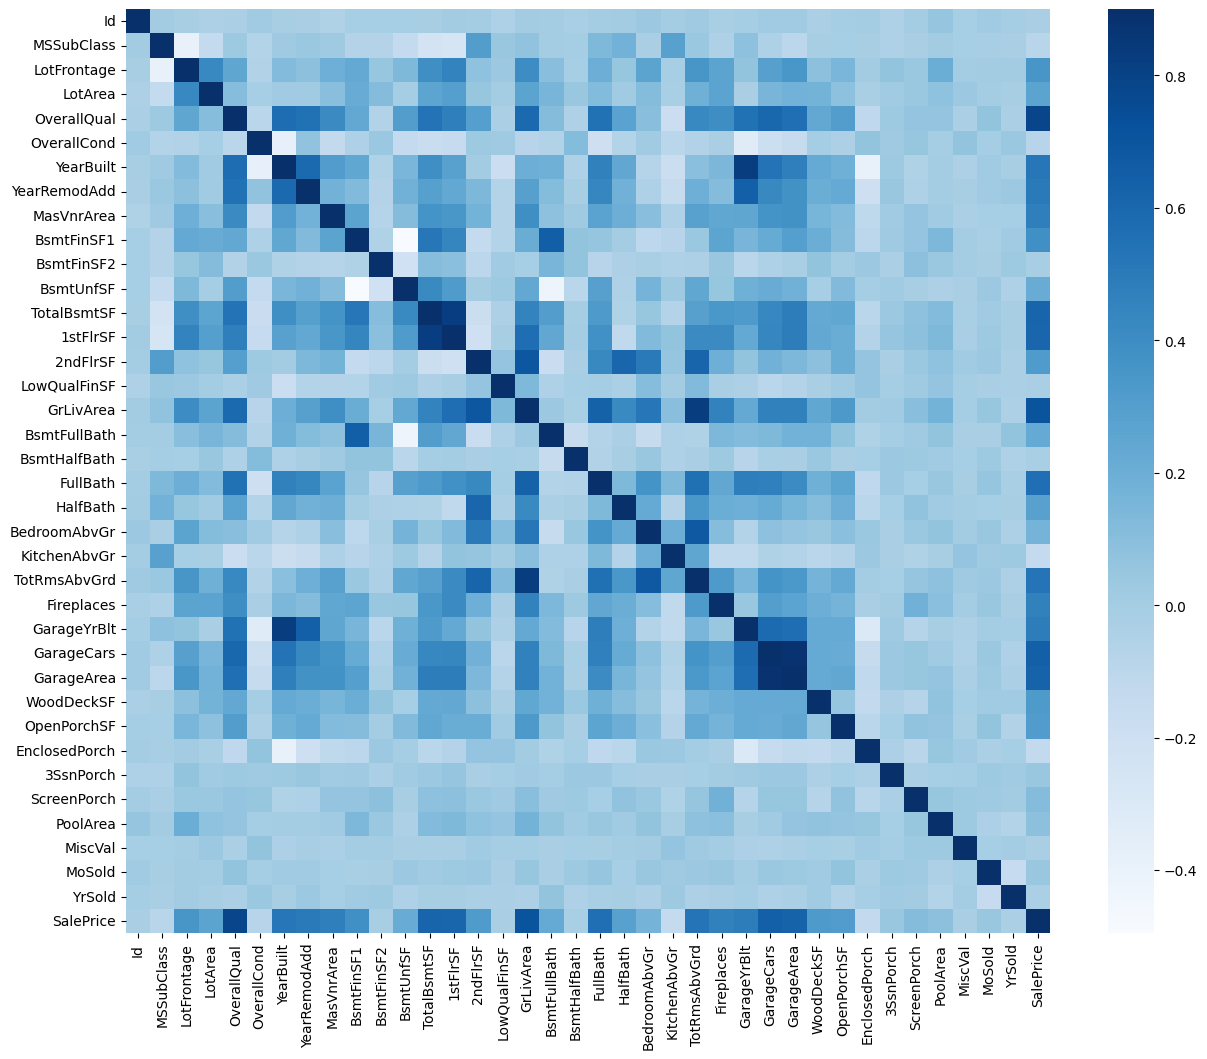

In [90]:
corr=train_df.corr(numeric_only=True)
plt.subplots(figsize=(15,12))
sns.heatmap(corr, vmax=0.9, cmap="Blues", square=True)


## 6. Outlier Removal

Remove extreme outliers based on domain knowledge:

- Low quality with high price
- Large area with unusually low price

In [91]:
train_df.drop(train_df[(train_df['OverallQual']<5) & (train_df['SalePrice']>200000)].index, inplace=True)
train_df.drop(train_df[(train_df['GrLivArea']>4500) & (train_df['SalePrice']<300000)].index, inplace=True)
train_df.reset_index(drop=True, inplace=True)

In [92]:
train_labels = train_df.copy()['SalePrice']
train_labels = np.log1p(train_labels)

In [93]:
train_features = train_df.copy().drop(['SalePrice'],axis=1)
test_features = test_df.copy()
all_features = pd.concat([train_features,test_features])
all_features

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


## 7. Missing Value Handling

Strategies include:

- Mode filling for categorical variables
- Median filling for numerical variables
- Group-based imputation
- Special handling for "None" categories

In [94]:
def percent_missing(df):
    data = pd.DataFrame(df)
    cols = data.columns
    dic_x = {}
    for i in range(0, len(cols)):
        dic_x.update({cols[i]:round(data[cols[i]].isnull().mean()*100,2)})
    return dic_x
missing = percent_missing(all_features)
dic_miss= sorted(missing.items(), key=lambda x:x[1], reverse=True)
dic_miss

[('PoolQC', np.float64(99.69)),
 ('MiscFeature', np.float64(96.4)),
 ('Alley', np.float64(93.21)),
 ('Fence', np.float64(80.42)),
 ('MasVnrType', np.float64(60.53)),
 ('FireplaceQu', np.float64(48.7)),
 ('LotFrontage', np.float64(16.63)),
 ('GarageYrBlt', np.float64(5.45)),
 ('GarageFinish', np.float64(5.45)),
 ('GarageQual', np.float64(5.45)),
 ('GarageCond', np.float64(5.45)),
 ('GarageType', np.float64(5.38)),
 ('BsmtCond', np.float64(2.81)),
 ('BsmtExposure', np.float64(2.81)),
 ('BsmtQual', np.float64(2.78)),
 ('BsmtFinType2', np.float64(2.74)),
 ('BsmtFinType1', np.float64(2.71)),
 ('MasVnrArea', np.float64(0.79)),
 ('MSZoning', np.float64(0.14)),
 ('Utilities', np.float64(0.07)),
 ('BsmtFullBath', np.float64(0.07)),
 ('BsmtHalfBath', np.float64(0.07)),
 ('Functional', np.float64(0.07)),
 ('Exterior1st', np.float64(0.03)),
 ('Exterior2nd', np.float64(0.03)),
 ('BsmtFinSF1', np.float64(0.03)),
 ('BsmtFinSF2', np.float64(0.03)),
 ('BsmtUnfSF', np.float64(0.03)),
 ('TotalBsmtSF', np

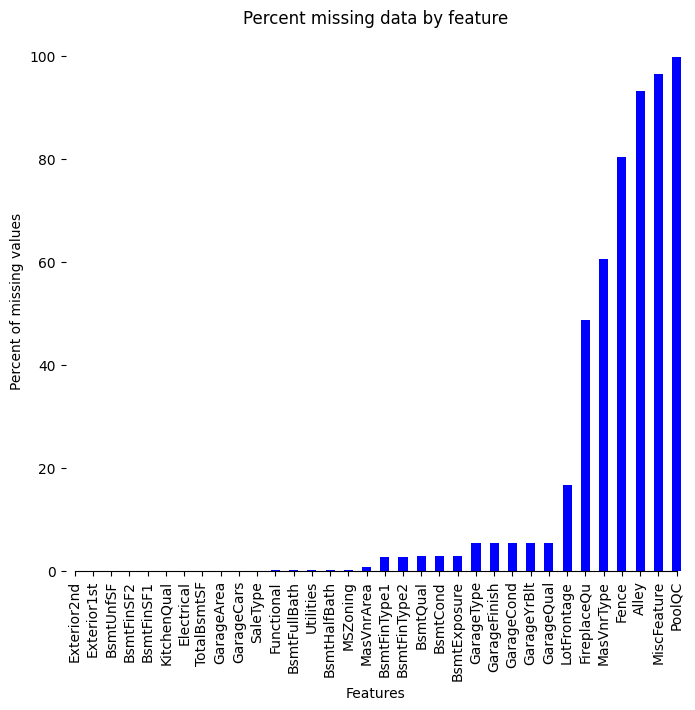

In [95]:
f, ax = plt.subplots(figsize=(8, 7))
train_df.isnull().mean()
missing = all_features.isnull().mean()*100
missing = missing[missing>0]
missing.sort_values(inplace = True)
missing.plot.bar(color="b")
ax.set(ylabel="Percent of missing values")
ax.set(xlabel="Features")
ax.set(title="Percent missing data by feature")
ax.set(ylabel="Percent of missing values")
ax.set(xlabel="Features")
ax.set(title="Percent missing data by feature")
sns.despine(trim=True, left=True)

In [96]:
all_features['MSSubClass'] = all_features['MSSubClass'].apply(str)
all_features['YrSold'] = all_features['YrSold'].astype(str)
all_features['MoSold'] = all_features['MoSold'].astype(str)

In [97]:
all_features['Functional'] =all_features['Functional'].fillna(all_features['Functional'].mode()[0])
all_features['Exterior2nd']=all_features['Exterior2nd'].fillna(all_features['Exterior2nd'].mode()[0])
all_features['Exterior1st']=all_features['Exterior1st'].fillna(all_features['Exterior1st'].mode()[0])
all_features['KitchenQual']=all_features['KitchenQual'].fillna(all_features['KitchenQual'].mode()[0])
all_features['SaleType']=all_features['SaleType'].fillna(all_features['SaleType'].mode()[0])


In [98]:
all_features['MSZoning'] = all_features.groupby('MSSubClass')['MSZoning'].transform(lambda x:x.fillna(x.mode()[0]))

all_features['LotFrontage'] = all_features.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [99]:
all_features["PoolQC"] = all_features["PoolQC"].fillna("None")
    # Replacing the missing values with 0, since no garage = no cars in garage
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_features[col] = all_features[col].fillna(0)
    # Replacing the missing values with None
for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    all_features[col] = all_features[col].fillna('None')
    # NaN values for these categorical basement features, means there's no basement
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_features[col] = all_features[col].fillna('None')

In [100]:
objects = all_features.select_dtypes(include=['object']).columns
all_features.update(all_features[objects].fillna('None'))


In [101]:
numeric = all_features.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns
all_features.update(all_features[numeric].fillna(0))


In [102]:
missing = percent_missing(all_features)
df_miss = sorted(missing.items(), key=lambda x:x[1], reverse=True)
df_miss

[('Id', np.float64(0.0)),
 ('MSSubClass', np.float64(0.0)),
 ('MSZoning', np.float64(0.0)),
 ('LotFrontage', np.float64(0.0)),
 ('LotArea', np.float64(0.0)),
 ('Street', np.float64(0.0)),
 ('Alley', np.float64(0.0)),
 ('LotShape', np.float64(0.0)),
 ('LandContour', np.float64(0.0)),
 ('Utilities', np.float64(0.0)),
 ('LotConfig', np.float64(0.0)),
 ('LandSlope', np.float64(0.0)),
 ('Neighborhood', np.float64(0.0)),
 ('Condition1', np.float64(0.0)),
 ('Condition2', np.float64(0.0)),
 ('BldgType', np.float64(0.0)),
 ('HouseStyle', np.float64(0.0)),
 ('OverallQual', np.float64(0.0)),
 ('OverallCond', np.float64(0.0)),
 ('YearBuilt', np.float64(0.0)),
 ('YearRemodAdd', np.float64(0.0)),
 ('RoofStyle', np.float64(0.0)),
 ('RoofMatl', np.float64(0.0)),
 ('Exterior1st', np.float64(0.0)),
 ('Exterior2nd', np.float64(0.0)),
 ('MasVnrType', np.float64(0.0)),
 ('MasVnrArea', np.float64(0.0)),
 ('ExterQual', np.float64(0.0)),
 ('ExterCond', np.float64(0.0)),
 ('Foundation', np.float64(0.0)),
 ('Bs

## 8. Feature Engineering

We construct new features to improve model performance.

### Numerical combinations
- Total square footage
- Total bathrooms
- Total porch area

### Time features
- HouseAge
- RemodAge

### Binary features
- HasGarage, HasPool, HasBsmt, etc.

### Interaction features
- OverallQual × GrLivArea

In [104]:
continuous_cols=[]
for col in numeric:
    if all_features[col].nunique() > 20:
        continuous_cols.append(col)

skew_values = all_features[continuous_cols].apply(lambda x: skew(x))
skew_features = skew_values[skew_values > 0.5].sort_values(ascending=False)
log_features=list(skew_features.index)
if 'HouseAge' in log_features:
    log_features.remove('HouseAge')
log_features

['MiscVal',
 'LotArea',
 'LowQualFinSF',
 '3SsnPorch',
 'BsmtFinSF2',
 'EnclosedPorch',
 'ScreenPorch',
 'MasVnrArea',
 'OpenPorchSF',
 'WoodDeckSF',
 '1stFlrSF',
 'LotFrontage',
 'GrLivArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 '2ndFlrSF',
 'TotalBsmtSF']

In [105]:
for col in log_features:
    all_features[col + '_log'] = np.log1p(all_features[col])

In [106]:
all_features['YrSold'] = all_features['YrSold'].astype(int)
all_features['YearBuilt'] = all_features['YearBuilt'].astype(int)
all_features['YearRemodAdd'] = all_features['YearRemodAdd'].astype(int)
def create_features(df):

    # ======================
    # math combination
    # ======================
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    df['Total_sqr_footage'] = (
        df['BsmtFinSF1'] + df['BsmtFinSF2'] +
        df['1stFlrSF'] + df['2ndFlrSF']
    )

    df['Total_porch_sf'] = (
        df['OpenPorchSF'] + df['3SsnPorch'] +
        df['EnclosedPorch'] + df['ScreenPorch'] +
        df['WoodDeckSF']
    )

    df['Total_Bathrooms'] = (
        df['FullBath'] +
        0.5 * df['HalfBath'] +
        df['BsmtFullBath'] +
        0.5 * df['BsmtHalfBath']
    )

    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

    df['Total_Home_Quality'] = df['OverallQual'] + df['OverallCond']


    # ======================
    # if exists
    # ======================
    df['HasPool'] =df['PoolArea'].apply(lambda x:1 if x>0 else 0)
    df['HasGarage'] = df['GarageArea'].apply(lambda x:1 if x>0 else 0)
    df['HasBsmt'] = df['TotalBsmtSF'].apply(lambda x:1 if x>0 else 0)
    df['HasFireplace'] = df['Fireplaces'].apply(lambda x:1 if x>0 else 0)
    df['Has2ndFloor'] = df['2ndFlrSF'].apply(lambda x:1 if x>0 else 0)

    # ======================
    # Count
    # ======================

    df['TotalAmenities'] = (
        df['HasPool'] +
        df['HasGarage'] +
        df['HasFireplace']+
        df['Has2ndFloor']
    )
    # ======================
    # mutal
    # ======================
    df['Qual_x_SF'] = df['OverallQual'] * df['GrLivArea']



    return df


all_features = create_features(all_features)

## 9. Encoding

- Apply one-hot encoding using `pd.get_dummies`
- Remove duplicate columns

In [ ]:
all_features = pd.get_dummies(all_features).reset_index(drop=True)
all_features = all_features.loc[:,~all_features.columns.duplicated()]
all_features = all_features.drop(['Id'], axis=1)

In [ ]:
X_train = all_features.iloc[:len(train_labels), :]
X_test  = all_features.iloc[len(train_labels):, :]

## 10. Model Building

We train multiple base models:

- Ridge Regression
- Random Forest
- Gradient Boosting
- LightGBM

In [ ]:
base_models = [
    ('ridge', Ridge()),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('lgb', LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
]

## 11. Stacking Ensemble

We combine multiple models using stacking:

### Base Models
- Ridge
- Random Forest
- Gradient Boosting
- LightGBM

### Final Model
- Ridge Regression

Cross-validation is used to improve generalization.

In [ ]:
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

## 12. Prediction and Submission

- Generate predictions on test data
- Apply inverse transformation using `expm1`
- Export results for Kaggle submission

In [ ]:
stack_model.fit(X_train, train_labels)

final_pred = stack_model.predict(X_test)

final_pred = np.expm1(final_pred)


submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": final_pred
})

submission.to_csv("submission.csv", index=False)
